In [17]:
# Validation
import data_loader
import evaluation
import template_matching
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import cv2

In [4]:
def validate_model(threshold, validation_set):
    """
    This method takes threshold for template_matching and validation_set
    Than it calculates and prints accuracy, precision, f1, recall
    Then show it's confussion matrix
    """
    validation_data = data_loader.load_and_preprocess_data(validation_set)

    validation_images = validation_data["images"]

    validation_labels = validation_data["ground_truth"]

    predictions = []

    for image in validation_images:
        result = template_matching.match_template(image, threshold)
        # no match is found
        if result["prediction"] == 0:
            predictions.append(None)    
        # match is found
        else:
            predictions.append(result["bbox"])
    
    #prediction is true if IoU is greater than 0.5
    confusion_matrix = evaluation.evaluate_predictions(predictions, validation_labels, 0.5)

    
    #flatten confussion matrix
    TN, FP, FN, TP = confusion_matrix.ravel()

    #calculate accuracy, precision, f1, recall
    accuracy = (TN + TP) / (TN + FP + FN + TP)
    
    if (FN + TP) != 0:
        recall = TP / (FN + TP)
    else:
        recall = "undefined"

    if (FP + TP) != 0:
        precision = TP / (FP + TP)
    else:
        precision = "undefined"
    
    if isinstance(recall, str) or isinstance(precision, str) or (recall + precision) == 0:
        f1_score = "undefined"
    else:
        f1_score = 2*(recall * precision) / (recall + precision)

    print(f"accuracy:{accuracy}")
    print(f"recall:{recall}")
    print(f"precision:{precision}")
    print(f"f1_score:{f1_score}")

    #visualization of confusion matrix
    confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=['No Match Found','Match Found'])
    confusion_matrix_display.plot()

    plt.title(f"Confussion Matrix For Threshold = {threshold}")
    plt.show()

## Validation

accuracy:0.005
recall:0.02
precision:0.006622516556291391
f1_score:0.009950248756218905


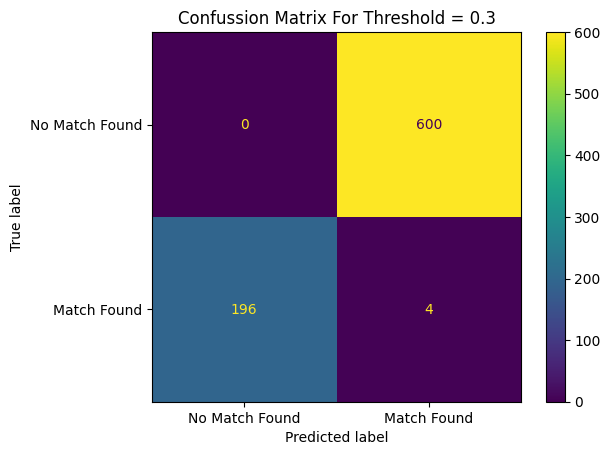

In [5]:
# Deney 1
# Threshold = 0.3
validate_model(0.3,"new_valid")

accuracy:0.00625
recall:0.02
precision:0.006633499170812604
f1_score:0.009962640099626401


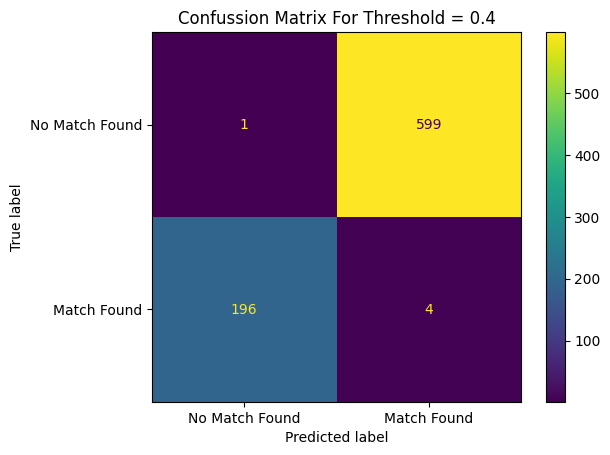

In [6]:
# Deney 2
# Threshold = 0.4
validate_model(0.4,"new_valid")

accuracy:0.10125
recall:0.005
precision:0.0019193857965451055
f1_score:0.002773925104022191


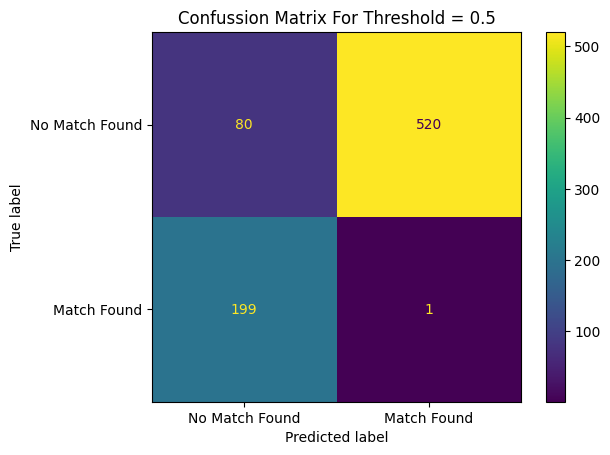

In [7]:
# Deney 3
# Threshold = 0.5
validate_model(0.5,"new_valid")

accuracy:0.74375
recall:0.0
precision:0.0
f1_score:undefined


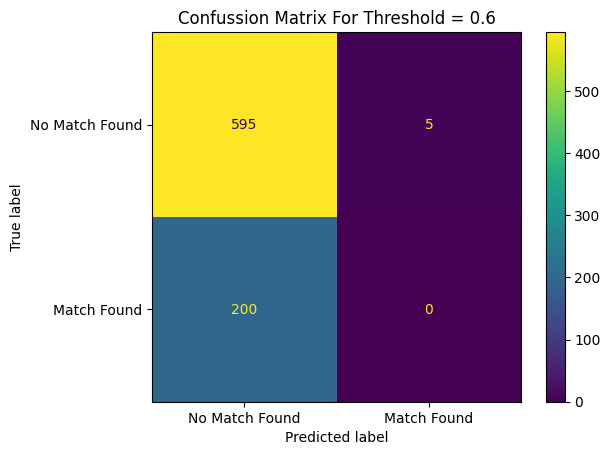

In [8]:
# Deney 4
# Threshold = 0.6
validate_model(0.6,"new_valid")

accuracy:0.75
recall:0.0
precision:undefined
f1_score:undefined


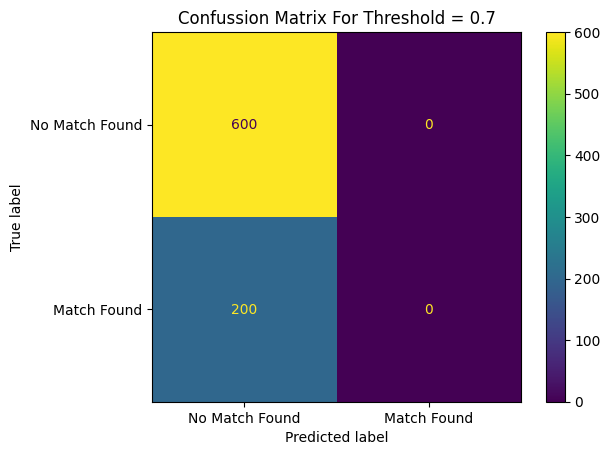

In [9]:
# Deney 5
# Threshold = 0.7
validate_model(0.7,"new_valid")

accuracy:0.01625
recall:0.02
precision:0.0067226890756302525
f1_score:0.010062893081761006


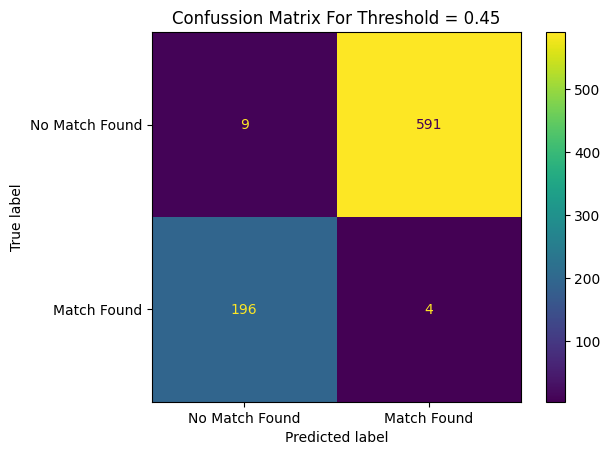

In [10]:
# Deney 6
# Threshold = 0.45
validate_model(0.45,"new_valid")

accuracy:0.03875
recall:0.015
precision:0.0052173913043478265
f1_score:0.007741935483870969


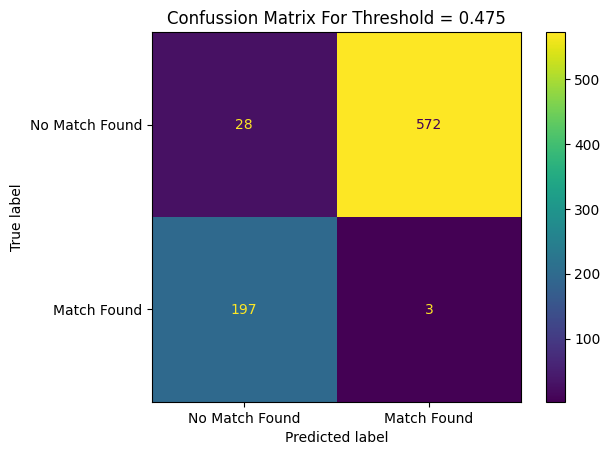

In [ ]:
# Deney 7
# Threshold = 0.475
validate_model(0.475,"new_valid")

accuracy:0.02125
recall:0.02
precision:0.00676818950930626
f1_score:0.01011378002528445


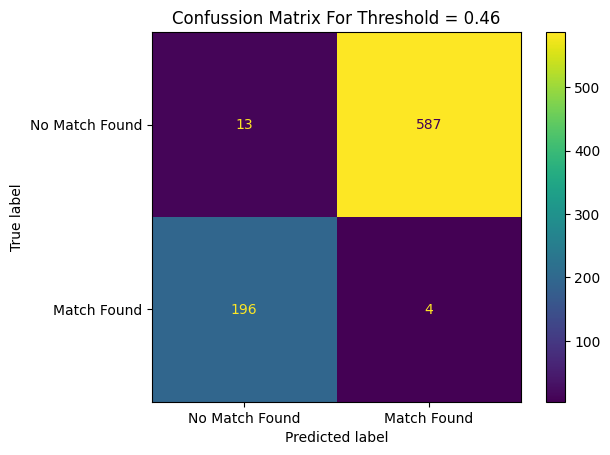

In [ ]:
# Deney 8
# Threshold = 0.46
validate_model(0.46,"new_valid")

accuracy:0.02625
recall:0.02
precision:0.0068143100511073255
f1_score:0.010165184243964422


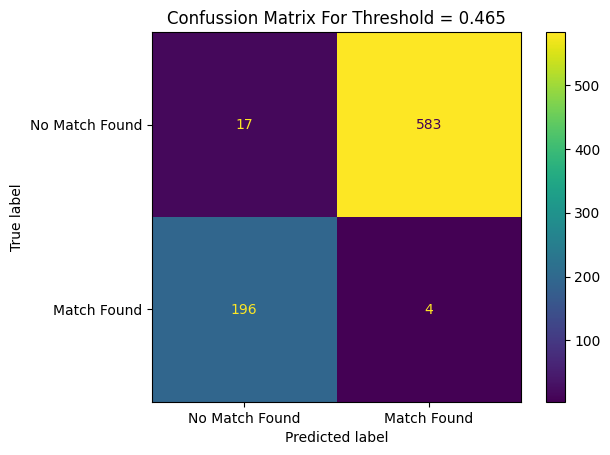

In [ ]:
# Deney 9
# Threshold = 0.465
validate_model(0.465,"new_valid")

accuracy:0.02875
recall:0.015
precision:0.005145797598627788
f1_score:0.007662835249042146


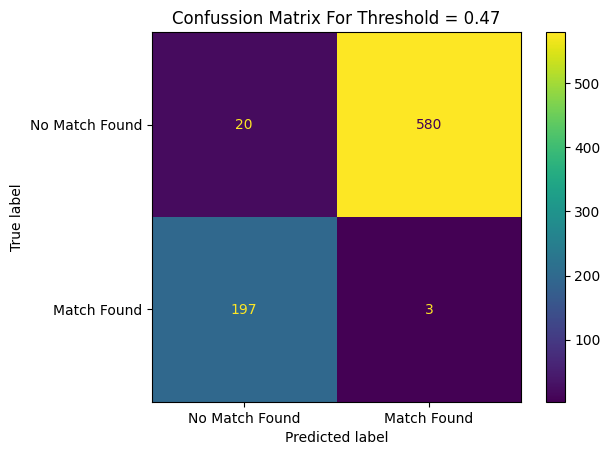

In [14]:
# Deney 10
# Threshold = 0.47
validate_model(0.47,"new_valid")

### Best threshold is 0.465 based on f1_score

## TEST

accuracy:0.04125
recall:0.045
precision:0.015384615384615385
f1_score:0.022929936305732486


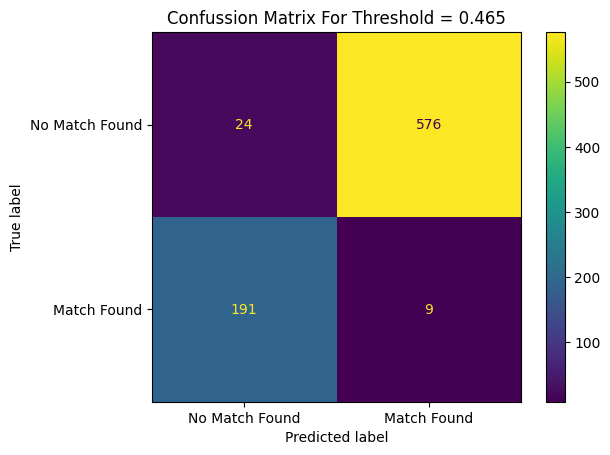

In [15]:
#Test
# Best Threshold = 0.465
validate_model(0.465,"new_test")

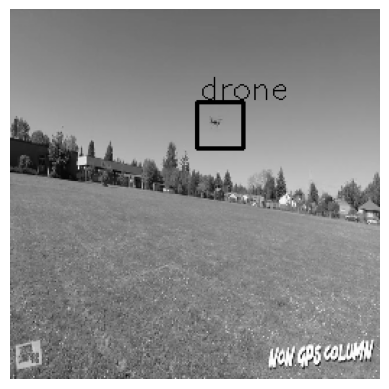

In [21]:
# Test code that shows template_matching on work

# while writting this code I took some snippet from our 
# validate_model(threshold, validation_set) method which defined in this file and 
# evaluate_predictions(predictions, ground_truths, area_threshold) method which defined 
# in evaluation.py file. Both methods are writen by us. 

validation_data = data_loader.load_and_preprocess_data("new_test")

validation_images = validation_data["images"]

validation_labels = validation_data["ground_truth"]

predictions = []

for image in validation_images:
    result = template_matching.match_template(image, 0.465)
    # no match is found
    if result["prediction"] == 0:
        predictions.append(None)    
    # match is found
    else:
        predictions.append(result["bbox"])

y_pred = []

for i in range(len(predictions)):
    pred = predictions[i]
    truth = validation_labels[i]

    if(truth is not None):
        if pred is not None:
            area_percent = evaluation.calculate_area_percentage(pred,truth)
            if(area_percent >= 0.5):
                # Model found the match with at least 0.5 IoU value
                
                #draw bbox
                image_with_bbox = validation_images[i].copy()
                # (0,0,255) for red color, 
                cv2.rectangle(image_with_bbox, (int(pred[0]), int(pred[1])), (int(pred[2]), int(pred[3])), (0,0,255), thickness=2)
                cv2.putText(image_with_bbox, "drone", (int(pred[0]) + 2, int(pred[1]) - 2), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.7,color=(0,0,255), thickness=1)
                
                #after drawing a red rectangle on image, the image turn from gray scale to BGR

                # turn image to RGB format to prevent color distortion
                image_with_bbox_rgb = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)

                plt.imshow(image_with_bbox_rgb)
                plt.axis('off')
                plt.show()
                break